In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import openpyxl
import seaborn as sns
import numpy as np
from jupyterlab.extensions.pypi import xmlrpc_transport_override
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score, roc_auc_score,balanced_accuracy_score
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import optuna

/opt/anaconda3/envs/main_py/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Prediction for 1 day

In [5]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_1_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')

In [6]:
sifts = range(1,30)

for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1924/935261532.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1924/935261532.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1924/935261532.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

# XGBoost

In [52]:

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

def objective(trial):

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params,dtrain=dtrain,evals=[(dtrain,'train'),(dtest,'test')],
                          num_boost_round=3000, early_stopping_rounds=50,verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///xgboost_for_1day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_1day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)


[I 2026-04-26 13:46:43,112] A new study created in RDB with name: xgboost_for_1day_study
Best trial: 0. Best value: 0.802306:   1%|          | 1/150 [00:04<10:01,  4.03s/it]

[I 2026-04-26 13:46:47,145] Trial 0 finished with value: 0.8023062605928899 and parameters: {'max_depth': 8, 'learning_rate': 0.08388879762014421, 'subsample': 0.6995928592033818, 'colsample_bytree': 0.9904680486987987, 'lambda': 9.1297436470254, 'alpha': 0.016496848078362242, 'gamma': 0.3319409896468839}. Best is trial 0 with value: 0.8023062605928899.


Best trial: 1. Best value: 0.803976:   1%|▏         | 2/150 [00:07<09:10,  3.72s/it]

[I 2026-04-26 13:46:50,640] Trial 1 finished with value: 0.8039761679473448 and parameters: {'max_depth': 5, 'learning_rate': 0.010627229764632587, 'subsample': 0.6781758071628063, 'colsample_bytree': 0.6491456370397928, 'lambda': 0.09287090987905405, 'alpha': 0.08372754569378658, 'gamma': 0.38226853011383344}. Best is trial 1 with value: 0.8039761679473448.


Best trial: 2. Best value: 0.805501:   2%|▏         | 3/150 [00:11<08:55,  3.65s/it]

...

[I 2026-04-26 14:03:34,910] Trial 147 finished with value: 0.8156052114418807 and parameters: {'max_depth': 6, 'learning_rate': 0.006921623566270825, 'subsample': 0.8094033611799504, 'colsample_bytree': 0.8015736757826123, 'lambda': 0.44430320824494374, 'alpha': 2.822966804777544, 'gamma': 4.120664463646236}. Best is trial 112 with value: 0.8200867187256298.


Best trial: 112. Best value: 0.820087:  99%|█████████▉| 149/150 [16:58<00:07,  7.86s/it]

[I 2026-04-26 14:03:41,183] Trial 148 finished with value: 0.8158797167604215 and parameters: {'max_depth': 5, 'learning_rate': 0.00816816855681882, 'subsample': 0.6877195740986506, 'colsample_bytree': 0.7803974514676717, 'lambda': 0.07071996252209213, 'alpha': 5.015515355997114, 'gamma': 4.361091951776555}. Best is trial 112 with value: 0.8200867187256298.


Best trial: 112. Best value: 0.820087: 100%|██████████| 150/150 [17:09<00:00,  6.86s/it]

[I 2026-04-26 14:03:52,689] Trial 149 finished with value: 0.817187776194982 and parameters: {'max_depth': 6, 'learning_rate': 0.006404874802735394, 'subsample': 0.7858984144716047, 'colsample_bytree': 0.7688961961521074, 'lambda': 0.16703979600151211, 'alpha': 2.221040404559252, 'gamma': 4.2101115123973765}. Best is trial 112 with value: 0.8200867187256298.


In [ ]:
study = optuna.load_study(storage='sqlite:///xgboost_for_1day_study.db',study_name='xgboost_for_1day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))


[0]	train-auc:0.82659	test-auc:0.65375
[50]	train-auc:0.98122	test-auc:0.78157
[100]	train-auc:0.99243	test-auc:0.79653
[150]	train-auc:0.99640	test-auc:0.80491
[200]	train-auc:0.99776	test-auc:0.80814
[250]	train-auc:0.99830	test-auc:0.81072
[300]	train-auc:0.99868	test-auc:0.81292
[350]	train-auc:0.99877	test-auc:0.81291
[400]	train-auc:0.99888	test-auc:0.81381
[450]	train-auc:0.99889	test-auc:0.81495
[500]	train-auc:0.99889	test-auc:0.81490
[550]	train-auc:0.99894	test-auc:0.81480
[586]	train-auc:0.99895	test-auc:0.81491
AUC 0.8149064706310503
Accuracy 0.8017135862913096
Precision 0.6871165644171779
Recall 0.2909090909090909
F1 0.40875912408759124


<Axes: >

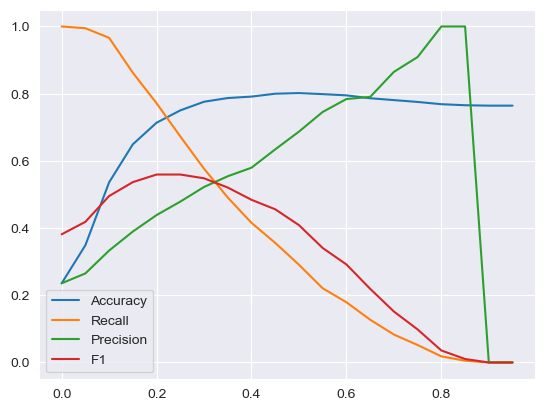

In [75]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')


# SVM 


In [5]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_1day_study.db',
    load_if_exists=True,
    study_name='svc_for_1day_study'
)           

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)


[I 2026-04-27 19:56:14,185] Using an existing study with name 'svc_for_1day_study' instead of creating a new one.
Best trial: 1. Best value: 0.714032:   1%|          | 1/150 [00:03<08:54,  3.59s/it]

[I 2026-04-27 19:56:17,775] Trial 1 finished with value: 0.7140320048246389 and parameters: {'kernel': 'poly', 'degree': 3}. Best is trial 1 with value: 0.7140320048246389.


Best trial: 1. Best value: 0.714032:   1%|▏         | 2/150 [00:07<08:51,  3.59s/it]

[I 2026-04-27 19:56:21,373] Trial 2 finished with value: 0.7140112089671737 and parameters: {'kernel': 'rbf', 'gamma': 2.4910094466791275}. Best is trial 1 with value: 0.7140320048246389.


Best trial: 3. Best value: 0.714072:   2%|▏         | 3/150 [00:10<08:48,  3.60s/it]

...

[I 2026-04-27 20:05:10,071] Trial 148 finished with value: 0.7140174477244132 and parameters: {'kernel': 'rbf', 'gamma': 0.04335415203602865}. Best is trial 76 with value: 0.7141006311542741.


Best trial: 76. Best value: 0.714101:  99%|█████████▉| 149/150 [08:59<00:03,  3.66s/it]

[I 2026-04-27 20:05:13,692] Trial 149 finished with value: 0.7139737764237364 and parameters: {'kernel': 'poly', 'degree': 3}. Best is trial 76 with value: 0.7141006311542741.


Best trial: 76. Best value: 0.714101: 100%|██████████| 150/150 [09:03<00:00,  3.62s/it]

[I 2026-04-27 20:05:17,334] Trial 150 finished with value: 0.7140382435818785 and parameters: {'kernel': 'rbf', 'gamma': 2.8282094678385903}. Best is trial 76 with value: 0.7141006311542741.


In [8]:
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_1day_study.db',study_name='svc_for_1day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))

AUC 0.5450739812629324
Accuracy 0.7643818849449204
Precision 0.0
Recall 0.0
F1 0.0


<Axes: >

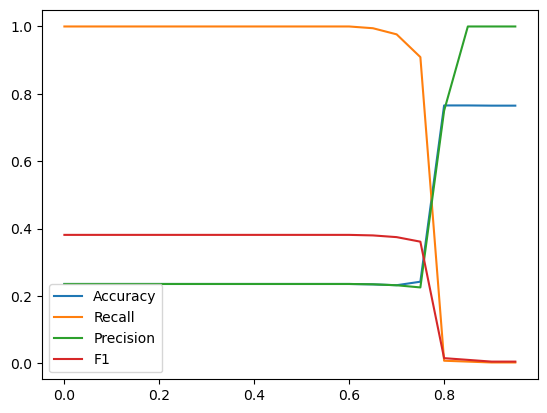

In [ ]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 0]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

<Axes: >

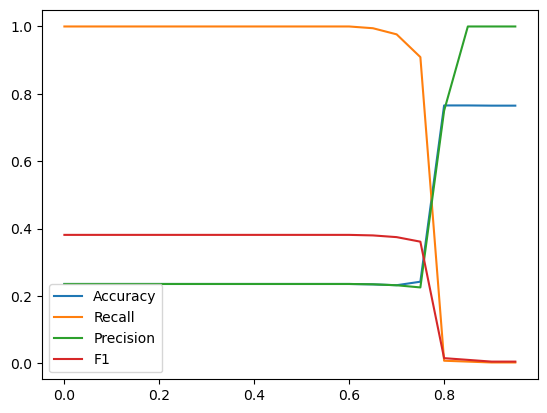

In [ ]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:,0]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# Prediction for 2 day

In [13]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_2_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')

In [14]:
sifts = range(1,30)

for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1924/935261532.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1924/935261532.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1924/935261532.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

# SVM

In [15]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_2day_study.db',
    load_if_exists=True,
    study_name='svc_for_2day_study'
)           

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)





[I 2026-04-27 20:23:38,616] A new study created in RDB with name: svc_for_2day_study
Best trial: 0. Best value: 0.731571:   1%|          | 1/150 [00:03<09:15,  3.73s/it]

[I 2026-04-27 20:23:42,348] Trial 0 finished with value: 0.7315712310107826 and parameters: {'kernel': 'rbf', 'gamma': 2.6871154305991376}. Best is trial 0 with value: 0.7315712310107826.


Best trial: 0. Best value: 0.731571:   1%|▏         | 2/150 [00:07<08:58,  3.64s/it]

[I 2026-04-27 20:23:45,926] Trial 1 finished with value: 0.7315514749461907 and parameters: {'kernel': 'rbf', 'gamma': 1.1857011257624732}. Best is trial 0 with value: 0.7315712310107826.


Best trial: 0. Best value: 0.731571:   2%|▏         | 3/150 [00:10<08:48,  3.59s/it]

...

[I 2026-04-27 20:34:15,812] Trial 147 finished with value: 0.7315421168103315 and parameters: {'kernel': 'poly', 'degree': 5}. Best is trial 69 with value: 0.7316149023114596.


Best trial: 69. Best value: 0.731615:  99%|█████████▉| 149/150 [10:42<00:05,  5.25s/it]

[I 2026-04-27 20:34:21,113] Trial 148 finished with value: 0.7315545943248105 and parameters: {'kernel': 'poly', 'degree': 4}. Best is trial 69 with value: 0.7316149023114596.


Best trial: 69. Best value: 0.731615: 100%|██████████| 150/150 [10:48<00:00,  4.32s/it]

[I 2026-04-27 20:34:27,008] Trial 149 finished with value: 0.7315504351533175 and parameters: {'kernel': 'rbf', 'gamma': 1.0292340359852012}. Best is trial 69 with value: 0.7316149023114596.


In [16]:
study = optuna.load_study(storage='sqlite:///svc_for_2day_study.db',study_name='svc_for_2day_study')
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))

AUC 0.6731327919478439
Accuracy 0.7674418604651163
Precision 0.6923076923076923
Recall 0.023376623376623377
F1 0.04522613065326633


<Axes: >

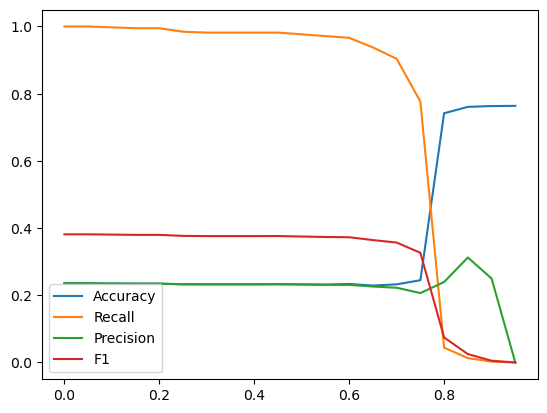

In [17]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 0]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# XGBoost

In [81]:

scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_2day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_2day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)


[I 2026-04-26 14:23:33,167] A new study created in RDB with name: xgboost_for_2day_study
Best trial: 0. Best value: 0.830609:   1%|          | 1/150 [00:07<18:26,  7.42s/it]

[I 2026-04-26 14:23:40,588] Trial 0 finished with value: 0.8306094226030174 and parameters: {'max_depth': 7, 'learning_rate': 0.013885346273348849, 'subsample': 0.9628121703915201, 'colsample_bytree': 0.6232065089489545, 'lambda': 0.001050353872566015, 'alpha': 0.005958048895214338, 'gamma': 2.7537504872338765}. Best is trial 0 with value: 0.8306094226030174.


Best trial: 0. Best value: 0.830609:   1%|▏         | 2/150 [00:09<10:38,  4.31s/it]

[I 2026-04-26 14:23:42,728] Trial 1 finished with value: 0.8218210932382268 and parameters: {'max_depth': 5, 'learning_rate': 0.09007292101406636, 'subsample': 0.6476328913426679, 'colsample_bytree': 0.6822559968790919, 'lambda': 0.009741215548923167, 'alpha': 0.16197005477295762, 'gamma': 0.7128377049181717}. Best is trial 0 with value: 0.8306094226030174.


Best trial: 2. Best value: 0.832063:   2%|▏         | 3/150 [00:12<08:39,  3.54s/it]

...

[I 2026-04-26 15:00:59,852] Trial 147 finished with value: 0.8385679972549467 and parameters: {'max_depth': 8, 'learning_rate': 0.005382772252659564, 'subsample': 0.5594624883958258, 'colsample_bytree': 0.7814759244054293, 'lambda': 0.028381016597191354, 'alpha': 1.7587603044701987, 'gamma': 4.991773065655438}. Best is trial 75 with value: 0.8452996163164298.


Best trial: 75. Best value: 0.8453:  99%|█████████▉| 149/150 [37:37<00:14, 14.26s/it]

[I 2026-04-26 15:01:11,031] Trial 148 finished with value: 0.8397845549166606 and parameters: {'max_depth': 7, 'learning_rate': 0.009310411024554799, 'subsample': 0.5687129300825741, 'colsample_bytree': 0.6784477580575301, 'lambda': 6.1850055040327865, 'alpha': 0.2208372102413039, 'gamma': 1.8747370284309217}. Best is trial 75 with value: 0.8452996163164298.


Best trial: 75. Best value: 0.8453: 100%|██████████| 150/150 [37:51<00:00, 15.15s/it]

[I 2026-04-26 15:01:25,142] Trial 149 finished with value: 0.8401900741372318 and parameters: {'max_depth': 8, 'learning_rate': 0.0074476514141448074, 'subsample': 0.6881840161073346, 'colsample_bytree': 0.7594794788458031, 'lambda': 2.6353582751852067, 'alpha': 0.8625744376424944, 'gamma': 4.694174194784834}. Best is trial 75 with value: 0.8452996163164298.


In [82]:
study = optuna.load_study(storage='sqlite:///xgboost_for_2day_study.db',study_name='xgboost_for_2day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

[0]	train-auc:0.84425	test-auc:0.67809
[50]	train-auc:0.99714	test-auc:0.79434
[100]	train-auc:0.99900	test-auc:0.80388
[150]	train-auc:0.99961	test-auc:0.81273
[200]	train-auc:0.99984	test-auc:0.81728
[250]	train-auc:0.99993	test-auc:0.82143
[300]	train-auc:0.99997	test-auc:0.82483
[350]	train-auc:0.99998	test-auc:0.82787
[400]	train-auc:0.99999	test-auc:0.82977
[450]	train-auc:1.00000	test-auc:0.83250
[500]	train-auc:1.00000	test-auc:0.83430
[550]	train-auc:1.00000	test-auc:0.83529
[600]	train-auc:1.00000	test-auc:0.83586
[650]	train-auc:1.00000	test-auc:0.83695
[700]	train-auc:1.00000	test-auc:0.83779
[750]	train-auc:1.00000	test-auc:0.83879
[800]	train-auc:1.00000	test-auc:0.83908
[850]	train-auc:1.00000	test-auc:0.83940
[900]	train-auc:1.00000	test-auc:0.83942
[950]	train-auc:1.00000	test-auc:0.83985
[1000]	train-auc:1.00000	test-auc:0.83983
[1050]	train-auc:1.00000	test-auc:0.84014
[1100]	train-auc:1.00000	test-auc:0.84022
[1150]	train-auc:1.00000	test-auc:0.84027
[1181]	train-au

<Axes: >

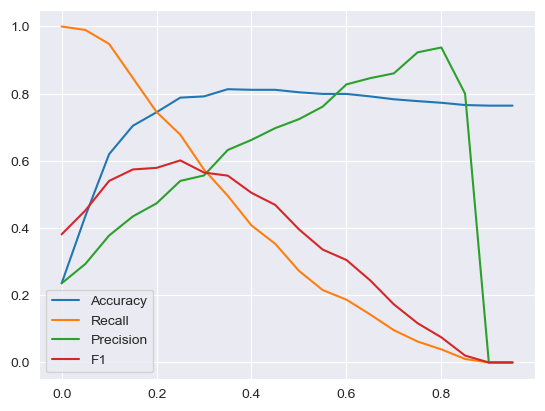

In [83]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# Prediction for 3 day

In [84]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_3_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')

In [85]:
sifts = range(1,30)

for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1403/1670350775.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1403/1670350775.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_1403/1670350775.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

# XGBoost

In [86]:

scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_3day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_3day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)


[I 2026-04-26 15:05:55,214] A new study created in RDB with name: xgboost_for_3day_study
Best trial: 0. Best value: 0.835535:   1%|          | 1/150 [00:02<07:06,  2.86s/it]

[I 2026-04-26 15:05:58,076] Trial 0 finished with value: 0.835535298035298 and parameters: {'max_depth': 5, 'learning_rate': 0.05741491476165211, 'subsample': 0.5470738758005855, 'colsample_bytree': 0.949696336397041, 'lambda': 0.07987991596844878, 'alpha': 0.0016153720809769997, 'gamma': 1.5530391037238356}. Best is trial 0 with value: 0.835535298035298.


Best trial: 1. Best value: 0.854212:   1%|▏         | 2/150 [00:08<11:45,  4.77s/it]

[I 2026-04-26 15:06:04,182] Trial 1 finished with value: 0.8542124542124542 and parameters: {'max_depth': 7, 'learning_rate': 0.015444181458544707, 'subsample': 0.5520080553028741, 'colsample_bytree': 0.8864854790725876, 'lambda': 0.02758188943660025, 'alpha': 0.0010898315019519857, 'gamma': 4.289250753373049}. Best is trial 1 with value: 0.8542124542124542.


Best trial: 1. Best value: 0.854212:   2%|▏         | 3/150 [00:16<15:01,  6.13s/it]

...

[I 2026-04-26 15:42:28,884] Trial 147 finished with value: 0.8544767732267732 and parameters: {'max_depth': 7, 'learning_rate': 0.0052567824947462385, 'subsample': 0.5598395975025643, 'colsample_bytree': 0.8593333722017878, 'lambda': 2.2851047721221884, 'alpha': 0.024422436584181566, 'gamma': 4.7147251576347395}. Best is trial 71 with value: 0.8583770396270396.


Best trial: 71. Best value: 0.858377:  99%|█████████▉| 149/150 [36:55<00:20, 20.26s/it]

[I 2026-04-26 15:42:50,458] Trial 148 finished with value: 0.8540521978021978 and parameters: {'max_depth': 8, 'learning_rate': 0.005603930452349592, 'subsample': 0.5020031588389603, 'colsample_bytree': 0.8792047901903162, 'lambda': 6.526547716426244, 'alpha': 0.04241399357218927, 'gamma': 4.79665749022062}. Best is trial 71 with value: 0.8583770396270396.


Best trial: 71. Best value: 0.858377: 100%|██████████| 150/150 [37:14<00:00, 14.90s/it]

[I 2026-04-26 15:43:09,830] Trial 149 finished with value: 0.8559003496503497 and parameters: {'max_depth': 8, 'learning_rate': 0.006299180353412023, 'subsample': 0.5152013783663548, 'colsample_bytree': 0.9302690511983921, 'lambda': 1.6505731217158317, 'alpha': 0.018694500333078283, 'gamma': 4.491150264088699}. Best is trial 71 with value: 0.8583770396270396.


In [89]:
study = optuna.load_study(storage='sqlite:///xgboost_for_3day_study.db',study_name='xgboost_for_3day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

[0]	train-auc:0.83138	test-auc:0.67483
[50]	train-auc:0.98652	test-auc:0.78774
[100]	train-auc:0.99105	test-auc:0.80751
[150]	train-auc:0.99371	test-auc:0.81637
[200]	train-auc:0.99606	test-auc:0.82559
[250]	train-auc:0.99722	test-auc:0.83017
[300]	train-auc:0.99808	test-auc:0.83295
[350]	train-auc:0.99856	test-auc:0.83593
[400]	train-auc:0.99876	test-auc:0.83720
[450]	train-auc:0.99895	test-auc:0.84049
[500]	train-auc:0.99912	test-auc:0.84169
[550]	train-auc:0.99921	test-auc:0.84342
[600]	train-auc:0.99932	test-auc:0.84452
[650]	train-auc:0.99940	test-auc:0.84536
[700]	train-auc:0.99946	test-auc:0.84690
[750]	train-auc:0.99952	test-auc:0.84768
[800]	train-auc:0.99955	test-auc:0.84834
[850]	train-auc:0.99958	test-auc:0.84920
[900]	train-auc:0.99959	test-auc:0.84961
[950]	train-auc:0.99962	test-auc:0.85019
[1000]	train-auc:0.99962	test-auc:0.85045
[1050]	train-auc:0.99962	test-auc:0.85104
[1100]	train-auc:0.99966	test-auc:0.85171
[1150]	train-auc:0.99966	test-auc:0.85178
[1200]	train-au

<Axes: >

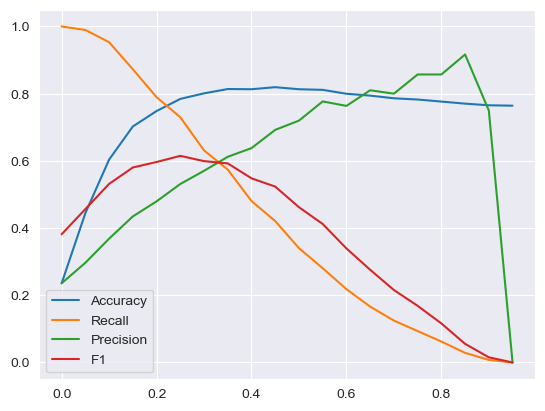

In [91]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# Prediction for 4 day

In [2]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_4_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/2017920725.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/2017920725.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/2017920725.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

# XGBoost

In [3]:

scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_4day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_4day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)


[I 2026-04-26 19:36:36,361] A new study created in RDB with name: xgboost_for_4day_study
Best trial: 0. Best value: 0.857176:   1%|          | 1/150 [00:01<03:27,  1.39s/it]

[I 2026-04-26 19:36:37,765] Trial 0 finished with value: 0.8571761571761571 and parameters: {'max_depth': 6, 'learning_rate': 0.08224939053549037, 'subsample': 0.6647457853919583, 'colsample_bytree': 0.915720086664668, 'lambda': 3.300717711727659, 'alpha': 0.013955991643061128, 'gamma': 4.7555831230474706}. Best is trial 0 with value: 0.8571761571761571.


Best trial: 1. Best value: 0.865475:   1%|▏         | 2/150 [00:09<13:10,  5.34s/it]

[I 2026-04-26 19:36:45,871] Trial 1 finished with value: 0.8654751498501497 and parameters: {'max_depth': 8, 'learning_rate': 0.010075220097836762, 'subsample': 0.8329252751337783, 'colsample_bytree': 0.5485632067339241, 'lambda': 0.0010295339024897258, 'alpha': 2.350846379350237, 'gamma': 4.14500138750822}. Best is trial 1 with value: 0.8654751498501497.


Best trial: 1. Best value: 0.865475:   2%|▏         | 3/150 [00:10<08:10,  3.34s/it]

...

[I 2026-04-26 21:06:50,544] Trial 147 finished with value: 0.8693743756243757 and parameters: {'max_depth': 5, 'learning_rate': 0.014166874562407094, 'subsample': 0.5918614136429404, 'colsample_bytree': 0.5099245880615992, 'lambda': 8.233834899529619, 'alpha': 0.03279586187738422, 'gamma': 3.100109365816187}. Best is trial 127 with value: 0.8724005161505162.


Best trial: 127. Best value: 0.872401:  99%|█████████▉| 149/150 [1:30:21<01:02, 62.68s/it]

[I 2026-04-26 21:06:58,305] Trial 148 finished with value: 0.870319264069264 and parameters: {'max_depth': 5, 'learning_rate': 0.022885433416898405, 'subsample': 0.614740462689654, 'colsample_bytree': 0.5580802181395951, 'lambda': 5.168977101356434, 'alpha': 0.05446519194106283, 'gamma': 2.6019908359259643}. Best is trial 127 with value: 0.8724005161505162.


Best trial: 127. Best value: 0.872401: 100%|██████████| 150/150 [1:30:32<00:00, 36.22s/it]

[I 2026-04-26 21:07:09,199] Trial 149 finished with value: 0.8700674325674325 and parameters: {'max_depth': 5, 'learning_rate': 0.022647681861234815, 'subsample': 0.6329675498072431, 'colsample_bytree': 0.5212810194863962, 'lambda': 5.00373818063732, 'alpha': 0.002582952650941181, 'gamma': 2.5626126365181263}. Best is trial 127 with value: 0.8724005161505162.


In [5]:
study = optuna.load_study(storage='sqlite:///xgboost_for_4day_study.db',study_name='xgboost_for_4day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

[0]	train-auc:0.79060	test-auc:0.67476
[50]	train-auc:0.96480	test-auc:0.80365
[100]	train-auc:0.98224	test-auc:0.82827
[150]	train-auc:0.99104	test-auc:0.84250
[200]	train-auc:0.99514	test-auc:0.85093
[250]	train-auc:0.99702	test-auc:0.85491
[300]	train-auc:0.99822	test-auc:0.85850
[350]	train-auc:0.99882	test-auc:0.86108
[400]	train-auc:0.99919	test-auc:0.86219
[450]	train-auc:0.99941	test-auc:0.86383
[500]	train-auc:0.99952	test-auc:0.86417
[550]	train-auc:0.99962	test-auc:0.86516
[600]	train-auc:0.99970	test-auc:0.86526
[650]	train-auc:0.99974	test-auc:0.86582
[700]	train-auc:0.99976	test-auc:0.86626
[750]	train-auc:0.99979	test-auc:0.86676
[800]	train-auc:0.99981	test-auc:0.86691
[850]	train-auc:0.99985	test-auc:0.86728
[900]	train-auc:0.99986	test-auc:0.86746
[950]	train-auc:0.99986	test-auc:0.86759
[1000]	train-auc:0.99987	test-auc:0.86792
[1050]	train-auc:0.99988	test-auc:0.86836
[1100]	train-auc:0.99988	test-auc:0.86829
[1150]	train-auc:0.99989	test-auc:0.86826
[1200]	train-au

<Axes: >

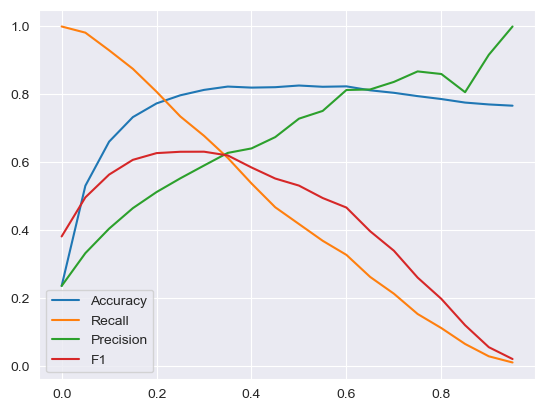

In [6]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# Prediction for 5 day

In [7]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_5_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/472125248.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/472125248.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/472125248.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

# XGBoost

In [8]:
scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_5day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_5day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)

[I 2026-04-26 22:26:16,125] A new study created in RDB with name: xgboost_for_5day_study
Best trial: 0. Best value: 0.863121:   1%|          | 1/150 [00:05<13:26,  5.41s/it]

[I 2026-04-26 22:26:21,535] Trial 0 finished with value: 0.8631208406669514 and parameters: {'max_depth': 8, 'learning_rate': 0.025653800283319126, 'subsample': 0.9266587915389275, 'colsample_bytree': 0.729797273316704, 'lambda': 0.03686618228559854, 'alpha': 0.0021993052778631773, 'gamma': 1.4215443050425436}. Best is trial 0 with value: 0.8631208406669514.


Best trial: 0. Best value: 0.863121:   1%|▏         | 2/150 [00:07<08:46,  3.56s/it]

[I 2026-04-26 22:26:23,793] Trial 1 finished with value: 0.8623355794165738 and parameters: {'max_depth': 2, 'learning_rate': 0.01661615498850598, 'subsample': 0.9778134335365296, 'colsample_bytree': 0.5193551695101215, 'lambda': 0.7166511094264503, 'alpha': 1.1374698867476747, 'gamma': 0.08049229635310295}. Best is trial 0 with value: 0.8631208406669514.


Best trial: 2. Best value: 0.868589:   2%|▏         | 3/150 [00:10<07:40,  3.13s/it]

...

[I 2026-04-26 22:46:19,805] Trial 147 finished with value: 0.8753996604838624 and parameters: {'max_depth': 8, 'learning_rate': 0.0053798701577200386, 'subsample': 0.5488825739702923, 'colsample_bytree': 0.5395272984061145, 'lambda': 8.306444545762993, 'alpha': 2.8322355807464215, 'gamma': 4.108453150708101}. Best is trial 122 with value: 0.8781532821629052.


Best trial: 122. Best value: 0.878153:  99%|█████████▉| 149/150 [20:16<00:13, 13.26s/it]

[I 2026-04-26 22:46:32,486] Trial 148 finished with value: 0.8753434216144722 and parameters: {'max_depth': 8, 'learning_rate': 0.00577840037616926, 'subsample': 0.5195966812462999, 'colsample_bytree': 0.5628200765441357, 'lambda': 4.373098891531327, 'alpha': 1.3293580602326063, 'gamma': 4.934844805726642}. Best is trial 122 with value: 0.8781532821629052.


Best trial: 122. Best value: 0.878153: 100%|██████████| 150/150 [20:26<00:00,  8.18s/it]

[I 2026-04-26 22:46:42,870] Trial 149 finished with value: 0.8740540934606692 and parameters: {'max_depth': 8, 'learning_rate': 0.006484229553247306, 'subsample': 0.5572566418005548, 'colsample_bytree': 0.5306971561268651, 'lambda': 3.958239033105914, 'alpha': 6.349661415351505, 'gamma': 4.710838124968157}. Best is trial 122 with value: 0.8781532821629052.


In [9]:
study = optuna.load_study(storage='sqlite:///xgboost_for_5day_study.db',study_name='xgboost_for_5day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

[0]	train-auc:0.81142	test-auc:0.67205
[50]	train-auc:0.99288	test-auc:0.82233
[100]	train-auc:0.99609	test-auc:0.83551
[150]	train-auc:0.99741	test-auc:0.84309
[200]	train-auc:0.99814	test-auc:0.85116
[250]	train-auc:0.99849	test-auc:0.85509
[300]	train-auc:0.99882	test-auc:0.85901
[350]	train-auc:0.99903	test-auc:0.86150
[400]	train-auc:0.99916	test-auc:0.86417
[450]	train-auc:0.99925	test-auc:0.86620
[500]	train-auc:0.99933	test-auc:0.86686
[550]	train-auc:0.99936	test-auc:0.86836
[600]	train-auc:0.99944	test-auc:0.86926
[650]	train-auc:0.99945	test-auc:0.86979
[700]	train-auc:0.99951	test-auc:0.87080
[750]	train-auc:0.99952	test-auc:0.87119
[800]	train-auc:0.99956	test-auc:0.87185
[850]	train-auc:0.99958	test-auc:0.87250
[900]	train-auc:0.99958	test-auc:0.87298
[950]	train-auc:0.99961	test-auc:0.87381
[1000]	train-auc:0.99961	test-auc:0.87440
[1050]	train-auc:0.99959	test-auc:0.87424
[1100]	train-auc:0.99960	test-auc:0.87480
[1150]	train-auc:0.99960	test-auc:0.87485
[1200]	train-au

<Axes: >

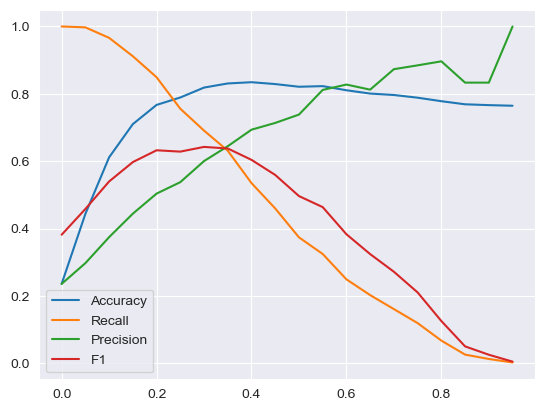

In [10]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# Prediction for 6 days


In [11]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_6_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/160863817.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/160863817.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/160863817.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

# XGBoost

In [12]:
scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_6day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_6day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)

[I 2026-04-26 22:57:28,816] A new study created in RDB with name: xgboost_for_6day_study
Best trial: 0. Best value: 0.880786:   1%|          | 1/150 [00:08<20:01,  8.07s/it]

[I 2026-04-26 22:57:36,881] Trial 0 finished with value: 0.8807860944188131 and parameters: {'max_depth': 5, 'learning_rate': 0.0097537271363978, 'subsample': 0.6109012857403269, 'colsample_bytree': 0.6213656260899981, 'lambda': 3.8094846964103737, 'alpha': 0.04170994391311531, 'gamma': 2.520467979911194}. Best is trial 0 with value: 0.8807860944188131.


Best trial: 0. Best value: 0.880786:   1%|▏         | 2/150 [00:16<20:08,  8.17s/it]

[I 2026-04-26 22:57:45,121] Trial 1 finished with value: 0.8772347139628616 and parameters: {'max_depth': 7, 'learning_rate': 0.015215129451924072, 'subsample': 0.7727334202370739, 'colsample_bytree': 0.9892967725218009, 'lambda': 1.7274171608084143, 'alpha': 1.6267113436881335, 'gamma': 2.2156628779008924}. Best is trial 0 with value: 0.8807860944188131.


Best trial: 0. Best value: 0.880786:   2%|▏         | 3/150 [00:17<12:26,  5.08s/it]

...

[I 2026-04-26 23:26:33,722] Trial 147 finished with value: 0.8830418979576958 and parameters: {'max_depth': 8, 'learning_rate': 0.007033138360281263, 'subsample': 0.5096091731565144, 'colsample_bytree': 0.5382022418856236, 'lambda': 2.9879149747431084, 'alpha': 0.04587411641810912, 'gamma': 3.52864180269585}. Best is trial 139 with value: 0.8854518376571303.


Best trial: 139. Best value: 0.885452:  99%|█████████▉| 149/150 [29:18<00:13, 13.89s/it]

[I 2026-04-26 23:26:47,678] Trial 148 finished with value: 0.8814026390610191 and parameters: {'max_depth': 8, 'learning_rate': 0.005916868829099681, 'subsample': 0.5399409781113388, 'colsample_bytree': 0.5117394719223654, 'lambda': 0.3269363183660522, 'alpha': 0.026411370664197322, 'gamma': 4.005449290438509}. Best is trial 139 with value: 0.8854518376571303.


Best trial: 139. Best value: 0.885452: 100%|██████████| 150/150 [29:32<00:00, 11.82s/it]

[I 2026-04-26 23:27:01,269] Trial 149 finished with value: 0.8814359657984357 and parameters: {'max_depth': 8, 'learning_rate': 0.006499926198901426, 'subsample': 0.55383112077353, 'colsample_bytree': 0.560754186287382, 'lambda': 2.214918477254025, 'alpha': 0.0964559534074561, 'gamma': 4.1121877303338294}. Best is trial 139 with value: 0.8854518376571303.


In [13]:
study = optuna.load_study(storage='sqlite:///xgboost_for_6day_study.db',study_name='xgboost_for_6day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

[0]	train-auc:0.82691	test-auc:0.65719
[50]	train-auc:0.98708	test-auc:0.81355
[100]	train-auc:0.99219	test-auc:0.82350
[150]	train-auc:0.99434	test-auc:0.83389
[200]	train-auc:0.99607	test-auc:0.84059
[250]	train-auc:0.99708	test-auc:0.84532
[300]	train-auc:0.99795	test-auc:0.85058
[350]	train-auc:0.99853	test-auc:0.85445
[400]	train-auc:0.99884	test-auc:0.85755
[450]	train-auc:0.99905	test-auc:0.86059
[500]	train-auc:0.99921	test-auc:0.86217
[550]	train-auc:0.99937	test-auc:0.86490
[600]	train-auc:0.99951	test-auc:0.86665
[650]	train-auc:0.99960	test-auc:0.86788
[700]	train-auc:0.99966	test-auc:0.86958
[750]	train-auc:0.99970	test-auc:0.87076
[800]	train-auc:0.99976	test-auc:0.87182
[850]	train-auc:0.99980	test-auc:0.87299
[900]	train-auc:0.99982	test-auc:0.87360
[950]	train-auc:0.99984	test-auc:0.87432
[1000]	train-auc:0.99986	test-auc:0.87490
[1050]	train-auc:0.99987	test-auc:0.87550
[1100]	train-auc:0.99988	test-auc:0.87605
[1150]	train-auc:0.99988	test-auc:0.87637
[1200]	train-au

<Axes: >

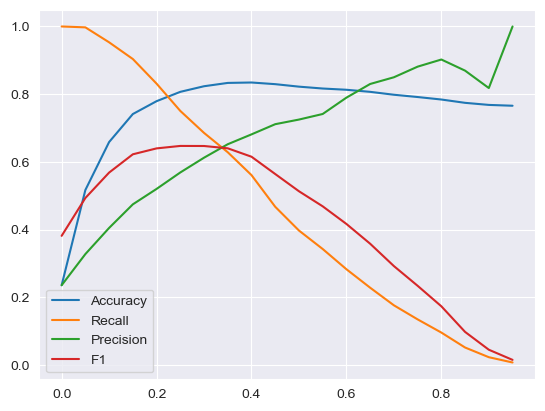

In [14]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# Prediction for 7 days

In [15]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_6_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change()
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/160863817.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data[j] = data[j].pct_change()
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/160863817.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{j}_lag_{sh}'] = data[j].shift(sh)
/var/folders/f5/kzrq0kqx07sb2j5ffctwkm4w0000gn/T/ipykernel_3047/160863817.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

# XGBoost

In [16]:
scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_7day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_7day_study'
)

study.optimize(
    objective,
    n_trials=150,
    show_progress_bar=True
)

[I 2026-04-26 23:29:11,054] A new study created in RDB with name: xgboost_for_7day_study
Best trial: 0. Best value: 0.874139:   1%|          | 1/150 [00:06<16:55,  6.82s/it]

[I 2026-04-26 23:29:17,868] Trial 0 finished with value: 0.8741394932252992 and parameters: {'max_depth': 3, 'learning_rate': 0.007179501314555814, 'subsample': 0.6622749219757333, 'colsample_bytree': 0.8655086816321629, 'lambda': 3.989202465160648, 'alpha': 0.1342645962912823, 'gamma': 0.09926497331480655}. Best is trial 0 with value: 0.8741394932252992.


Best trial: 0. Best value: 0.874139:   1%|▏         | 2/150 [00:08<09:05,  3.69s/it]

[I 2026-04-26 23:29:19,365] Trial 1 finished with value: 0.8657411553963278 and parameters: {'max_depth': 7, 'learning_rate': 0.07414909122292643, 'subsample': 0.822479899590741, 'colsample_bytree': 0.7166206005856597, 'lambda': 1.3928172584654577, 'alpha': 0.06485269343111648, 'gamma': 3.996914571758622}. Best is trial 0 with value: 0.8741394932252992.


Best trial: 0. Best value: 0.874139:   2%|▏         | 3/150 [00:09<06:08,  2.50s/it]

...

[I 2026-04-27 00:01:00,938] Trial 147 finished with value: 0.8822295587331673 and parameters: {'max_depth': 7, 'learning_rate': 0.00867763170751102, 'subsample': 0.5101950255346717, 'colsample_bytree': 0.9174784104247113, 'lambda': 8.241419737824218, 'alpha': 0.43259058059138555, 'gamma': 3.1132972535307855}. Best is trial 112 with value: 0.8857746904258532.


Best trial: 112. Best value: 0.885775:  99%|█████████▉| 149/150 [31:59<00:15, 15.14s/it]

[I 2026-04-27 00:01:10,350] Trial 148 finished with value: 0.8792155719180579 and parameters: {'max_depth': 7, 'learning_rate': 0.018183902957778456, 'subsample': 0.543186694970453, 'colsample_bytree': 0.8486360045318758, 'lambda': 9.70557736291306, 'alpha': 0.1712952455442527, 'gamma': 3.206200903074969}. Best is trial 112 with value: 0.8857746904258532.


Best trial: 112. Best value: 0.885775: 100%|██████████| 150/150 [32:26<00:00, 12.98s/it]

[I 2026-04-27 00:01:37,755] Trial 149 finished with value: 0.8815296972474198 and parameters: {'max_depth': 7, 'learning_rate': 0.005108309991892953, 'subsample': 0.527987724033607, 'colsample_bytree': 0.8160637369468193, 'lambda': 5.12221514844958, 'alpha': 2.6475347275890013, 'gamma': 2.757070810889186}. Best is trial 112 with value: 0.8857746904258532.


In [ ]:
study = optuna.load_study(storage='sqlite:///xgboost_for_7day_study.db',study_name='xgboost_for_7day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=50
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

[0]	train-auc:0.80131	test-auc:0.64946
[50]	train-auc:0.97290	test-auc:0.80005
[100]	train-auc:0.98226	test-auc:0.81577
[150]	train-auc:0.98785	test-auc:0.82993
[200]	train-auc:0.99153	test-auc:0.83877
[250]	train-auc:0.99366	test-auc:0.84610
[300]	train-auc:0.99523	test-auc:0.85208
[350]	train-auc:0.99636	test-auc:0.85615
[400]	train-auc:0.99693	test-auc:0.85968
[450]	train-auc:0.99733	test-auc:0.86247
[500]	train-auc:0.99769	test-auc:0.86482
[550]	train-auc:0.99791	test-auc:0.86622
[600]	train-auc:0.99826	test-auc:0.86809
[650]	train-auc:0.99845	test-auc:0.86994
[700]	train-auc:0.99861	test-auc:0.87131
[750]	train-auc:0.99872	test-auc:0.87233
[800]	train-auc:0.99890	test-auc:0.87322
[850]	train-auc:0.99897	test-auc:0.87474
[900]	train-auc:0.99906	test-auc:0.87538
[950]	train-auc:0.99913	test-auc:0.87590
[1000]	train-auc:0.99919	test-auc:0.87648
[1050]	train-auc:0.99923	test-auc:0.87689
[1100]	train-auc:0.99928	test-auc:0.87720
[1150]	train-auc:0.99931	test-auc:0.87770
[1200]	train-au

<Axes: >

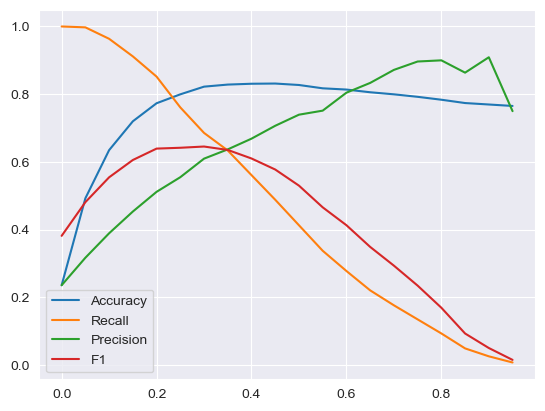

In [ ]:
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')